In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Add src/ to path so we can import our modules
sys.path.append(os.path.join(os.path.dirname(''), 'src'))

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('darkgrid')

print("All imports OK")

All imports OK


In [2]:
RAW_DIR = '../data/raw'
TRAIN_DIR = os.path.join(RAW_DIR, 'train')
 
def load_week(week):
    w = str(week).zfill(2)
    inp = pd.read_csv(os.path.join(TRAIN_DIR, f'input_2023_w{w}.csv'))
    out = pd.read_csv(os.path.join(TRAIN_DIR, f'output_2023_w{w}.csv'))
    inp['week'] = week
    out['week'] = week
    return inp, out
 
inp1, out1 = load_week(1)
print(f"Input shape:  {inp1.shape}")
print(f"Output shape: {out1.shape}")
print(f"\nInput columns:\n{list(inp1.columns)}")

Input shape:  (285714, 24)
Output shape: (32088, 7)

Input columns:
['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'week']


In [3]:
sup = pd.read_csv(os.path.join(RAW_DIR, 'supplementary_data.csv'))
print(f"Supplementary shape: {sup.shape}")
print(f"\nColumns:\n{list(sup.columns)}")

Supplementary shape: (18009, 41)

Columns:
['game_id', 'season', 'week', 'game_date', 'game_time_eastern', 'home_team_abbr', 'visitor_team_abbr', 'play_id', 'play_description', 'quarter', 'game_clock', 'down', 'yards_to_go', 'possession_team', 'defensive_team', 'yardline_side', 'yardline_number', 'pre_snap_home_score', 'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result', 'pass_length', 'offense_formation', 'receiver_alignment', 'route_of_targeted_receiver', 'play_action', 'dropback_type', 'dropback_distance', 'pass_location_type', 'defenders_in_the_box', 'team_coverage_man_zone', 'team_coverage_type', 'penalty_yards', 'pre_penalty_yards_gained', 'yards_gained', 'expected_points', 'expected_points_added', 'pre_snap_home_team_win_probability', 'pre_snap_visitor_team_win_probability', 'home_team_win_probability_added', 'visitor_team_win_probility_added']


C:\Users\rohit\AppData\Local\Temp\ipykernel_26224\2503823999.py:1: DtypeWarning: Columns (0: play_action) have mixed types. Specify dtype option on import or set low_memory=False.
  sup = pd.read_csv(os.path.join(RAW_DIR, 'supplementary_data.csv'))


In [4]:
from tqdm import tqdm
 
all_inputs, all_outputs = [], []
for week in tqdm(range(1, 19), desc="Loading weeks"):
    try:
        inp, out = load_week(week)
        all_inputs.append(inp)
        all_outputs.append(out)
    except FileNotFoundError:
        print(f"Week {week} not found, skipping")
 
df_input = pd.concat(all_inputs, ignore_index=True)
df_output = pd.concat(all_outputs, ignore_index=True)
 
print(f"\nFull input shape:  {df_input.shape}")
print(f"Full output shape: {df_output.shape}")

Loading weeks: 100%|██████████| 18/18 [00:25<00:00,  1.42s/it]



Full input shape:  (4880579, 24)
Full output shape: (562936, 7)


In [5]:
print("=== INPUT NULL COUNTS ===")
print(df_input.isnull().sum()[df_input.isnull().sum() > 0])
 
print("\n=== KEY COLUMN DISTRIBUTIONS ===")
print(df_input[['s', 'a', 'x', 'y']].describe().round(2))
 
print("\n=== PLAYER ROLES ===")
print(df_input['player_role'].value_counts())
 
print("\n=== PLAYER SIDES ===")
print(df_input['player_side'].value_counts())

=== INPUT NULL COUNTS ===
Series([], dtype: int64)

=== KEY COLUMN DISTRIBUTIONS ===
                s           a           x           y
count  4880579.00  4880579.00  4880579.00  4880579.00
mean         3.02        2.12       60.50       26.81
std          2.23        1.42       23.49       10.01
min          0.00        0.00        0.41        0.62
25%          1.09        1.01       42.63       18.99
50%          2.72        1.92       60.41       26.85
75%          4.62        3.04       78.23       34.62
max         12.53       17.12      119.86       52.88

=== PLAYER ROLES ===
player_role
Defensive Coverage    2662657
Other Route Runner    1424243
Targeted Receiver      396914
Passer                 396765
Name: count, dtype: int64

=== PLAYER SIDES ===
player_side
Defense    2662657
Offense    2217922
Name: count, dtype: int64


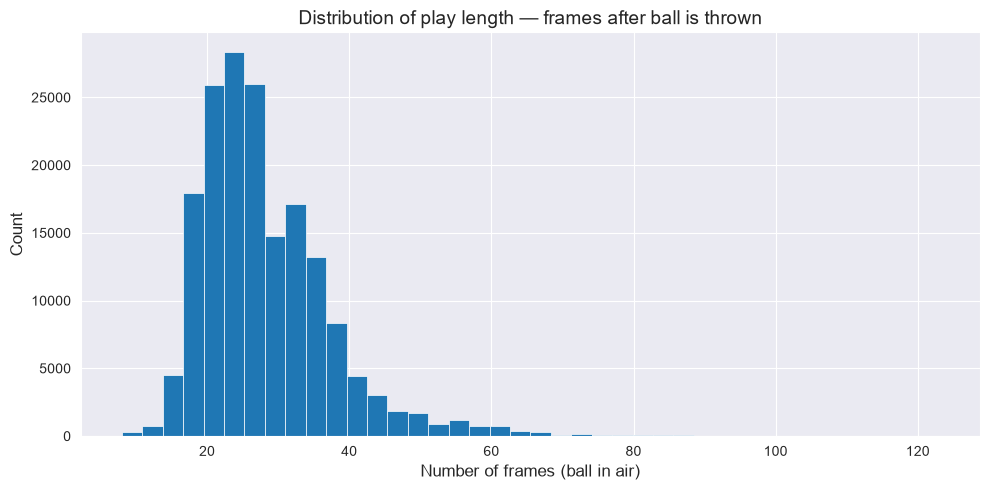

Median frames: 26
Mean frames:   28.2


In [6]:
frames_per_play = df_input.groupby(['game_id', 'play_id', 'nfl_id'])['frame_id'].max().reset_index()
frames_per_play.columns = ['game_id', 'play_id', 'nfl_id', 'num_frames']
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(frames_per_play['num_frames'], bins=40, color='#1f77b4', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of frames (ball in air)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of play length — frames after ball is thrown', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'frame_count_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Median frames: {frames_per_play['num_frames'].median():.0f}")
print(f"Mean frames:   {frames_per_play['num_frames'].mean():.1f}")

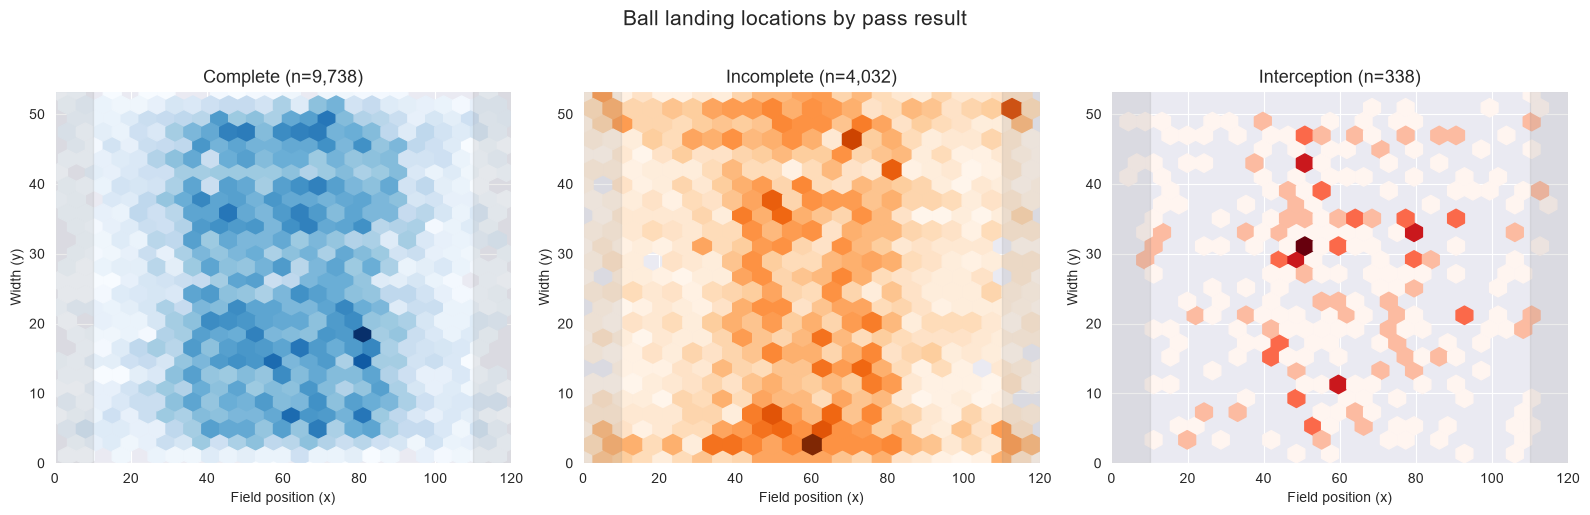

In [7]:
df_plays = df_input[['game_id', 'play_id', 'ball_land_x', 'ball_land_y']].drop_duplicates()
df_plays = df_plays.merge(
    sup[['game_id', 'play_id', 'pass_result']],
    on=['game_id', 'play_id'],
    how='left'
)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
results = {'C': 'Complete', 'I': 'Incomplete', 'IN': 'Interception'}
colors = {'C': 'Blues', 'I': 'Oranges', 'IN': 'Reds'}
 
for ax, (code, label) in zip(axes, results.items()):
    subset = df_plays[df_plays['pass_result'] == code]
    ax.hexbin(subset['ball_land_x'], subset['ball_land_y'],
              gridsize=25, cmap=colors[code], mincnt=1)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_title(f'{label} (n={len(subset):,})', fontsize=13)
    ax.set_xlabel('Field position (x)')
    ax.set_ylabel('Width (y)')
    # Draw end zones
    ax.axvspan(0, 10, alpha=0.15, color='gray')
    ax.axvspan(110, 120, alpha=0.15, color='gray')
 
plt.suptitle('Ball landing locations by pass result', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ball_landing_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_26224\724472751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x='player_role', y=metric,
C:\Users\rohit\AppData\Local\Temp\ipykernel_26224\724472751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x='player_role', y=metric,


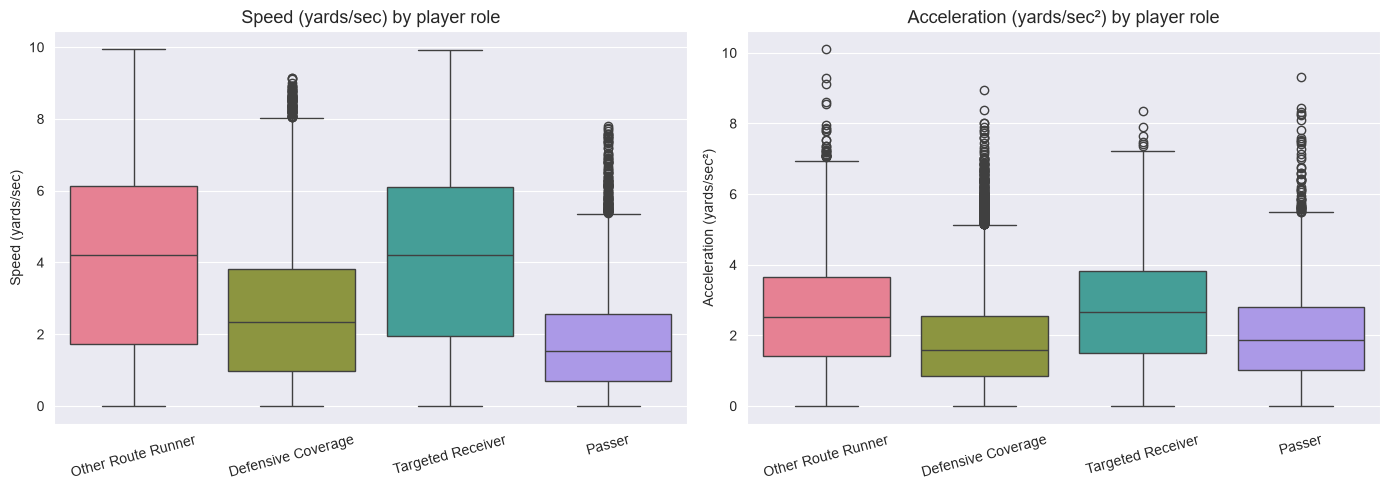

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
roles = df_input['player_role'].dropna().unique()
palette = sns.color_palette("husl", len(roles))
 
for i, metric in enumerate(['s', 'a']):
    label = 'Speed (yards/sec)' if metric == 's' else 'Acceleration (yards/sec²)'
    sample = df_input[df_input['player_role'].notna()].sample(min(50000, len(df_input)), random_state=42)
    sns.boxplot(data=sample, x='player_role', y=metric,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{label} by player role', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(label)
    axes[i].tick_params(axis='x', rotation=15)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'speed_accel_by_role.png'), dpi=150, bbox_inches='tight')
plt.show()

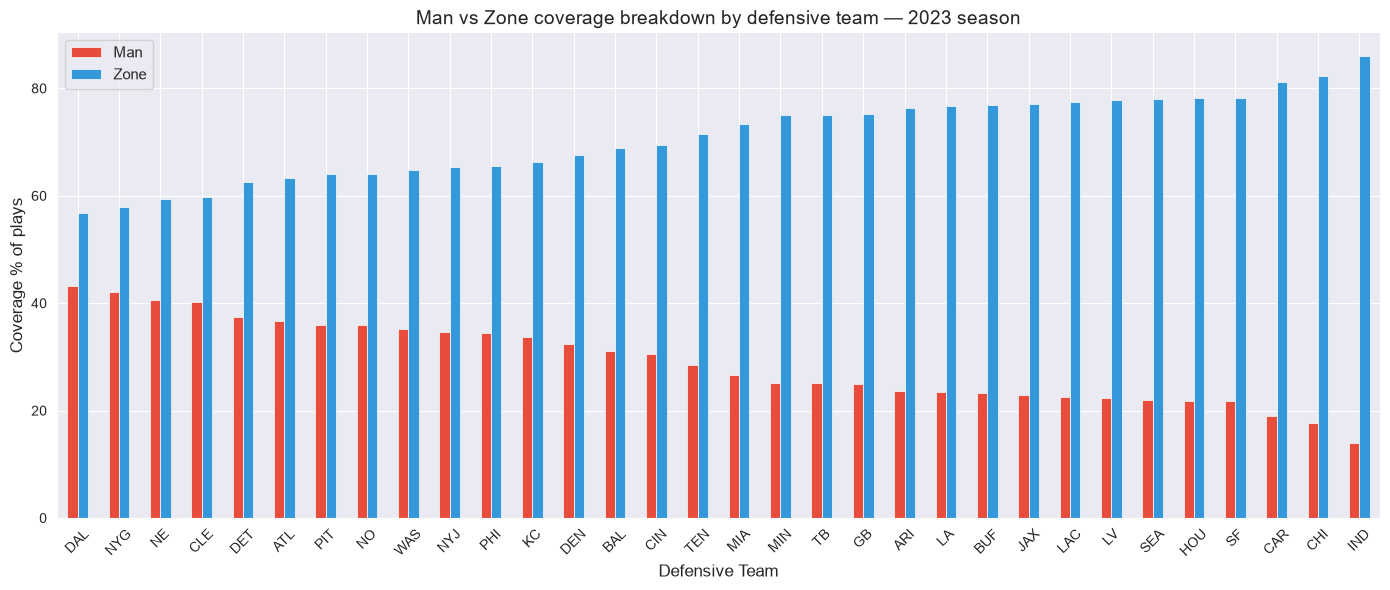

In [13]:
coverage_counts = sup.groupby(['defensive_team', 'team_coverage_man_zone']).size().unstack(fill_value=0)
coverage_pct = coverage_counts.div(coverage_counts.sum(axis=1), axis=0) * 100
coverage_pct = coverage_pct.sort_values('MAN_COVERAGE', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
coverage_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Defensive Team', fontsize=12)
ax.set_ylabel('Coverage % of plays', fontsize=12)
ax.set_title('Man vs Zone coverage breakdown by defensive team — 2023 season', fontsize=14)
ax.legend(['Man', 'Zone'], fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'man_zone_by_team.png'), dpi=150, bbox_inches='tight')
plt.show()

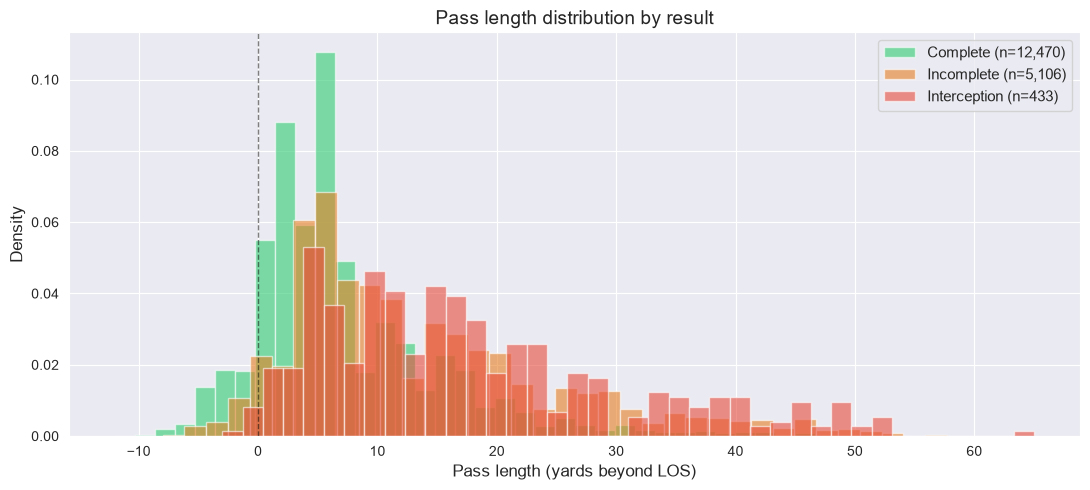

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for result, color, label in [('C', '#2ecc71', 'Complete'), 
                               ('I', '#e67e22', 'Incomplete'), 
                               ('IN', '#e74c3c', 'Interception')]:
    data = sup[sup['pass_result'] == result]['pass_length'].dropna()
    ax.hist(data, bins=40, alpha=0.6, color=color, label=f'{label} (n={len(data):,})', density=True)
 
ax.set_xlabel('Pass length (yards beyond LOS)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Pass length distribution by result', fontsize=14)
ax.legend(fontsize=11)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Line of scrimmage')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pass_length_by_result.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=== SUMMARY FOR FEATURE ENGINEERING ===\n")
 
catch_rate = (sup['pass_result'] == 'C').mean()
print(f"Overall catch rate: {catch_rate:.1%}")
 
print(f"\nPass result breakdown:")
print(sup['pass_result'].value_counts(normalize=True).round(3))
 
print(f"\nAvg pass length by result:")
print(sup.groupby('pass_result')['pass_length'].mean().round(1))
 
print(f"\nCoverage type breakdown:")
print(sup['team_coverage_man_zone'].value_counts(normalize=True).round(3))
 
print(f"\nFormation breakdown:")
print(sup['offense_formation'].value_counts().head(8))
 
print("\n=== EDA COMPLETE — ready for feature engineering ===")

=== SUMMARY FOR FEATURE ENGINEERING ===

Overall catch rate: 69.2%

Pass result breakdown:
pass_result
C     0.692
I     0.284
IN    0.024
Name: proportion, dtype: float64

Avg pass length by result:
pass_result
C      7.2
I     13.4
IN    17.6
Name: pass_length, dtype: float64

Coverage type breakdown:
team_coverage_man_zone
ZONE_COVERAGE    0.71
MAN_COVERAGE     0.29
Name: proportion, dtype: float64

Formation breakdown:
offense_formation
SHOTGUN       12768
EMPTY          2122
SINGLEBACK     2059
PISTOL          624
I_FORM          394
JUMBO            39
WILDCAT           3
Name: count, dtype: int64

=== EDA COMPLETE — ready for feature engineering ===


In [12]:
print(sup['team_coverage_man_zone'].value_counts())
print(coverage_pct.columns.tolist())

team_coverage_man_zone
ZONE_COVERAGE    12783
MAN_COVERAGE      5221
Name: count, dtype: int64
['MAN_COVERAGE', 'ZONE_COVERAGE']
